<a href="https://colab.research.google.com/github/LaerteKimura/FIAP_trabalho_ML_Diagnostico/blob/main/FIAP_trabalho_ML_Diagnostico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **POSTECH - IA para Devs - Tech Challenge - Fase 1**

**GRUPO 63**

*   Felipe Demétrius Martins da Silva - RM 367962
*   Kauê Bove Martins - RM 367999
*   Laerte Kimura - RM 368091
*   Thiago Albuquerque Rosa - RM 366838
*   Vinicius Otavio Soares da Silva - RM 367861

**DATASET**

Para o presente trabalho, o grupo escolheu um dos datasets sugeridos no próprio enunciado do Tech Challenge: o [Diabetes Data Set](https://www.kaggle.com/datasets/mathchi/diabetes-data-set/data), disponível no Kaggle (autor: mathchi).

Esse conjunto de dados foi originalmente coletado pelo **National Institute of Diabetes and Digestive and Kidney Diseases** e contém **768 registros de pacientes**, com informações clínicas e fisiológicas relacionadas ao diagnóstico de **diabetes tipo 2**.

O objetivo principal é **prever se um paciente tem ou não diabetes**, a partir de medidas coletadas em exames de rotina.
A variável alvo é `Outcome`, que assume valor **1** para pacientes com diagnóstico positivo e **0** para negativos.


**Atributos do dataset**

O conjunto de dados contém 8 atributos de entrada e 1 atributo alvo (`Outcome`):

| Coluna                       | Descrição                                                           |
| :--------------------------- | :------------------------------------------------------------------ |
| **Pregnancies**              | Número de vezes que a paciente ficou grávida.                       |
| **Glucose**                  | Nível de glicose no sangue após teste oral de tolerância à glicose. |
| **BloodPressure**            | Pressão arterial diastólica (em mm Hg).                             |
| **SkinThickness**            | Espessura da dobra cutânea do tríceps (em mm).                      |
| **Insulin**                  | Nível de insulina sérica em jejum (mu U/ml).                        |
| **BMI**                      | Índice de massa corporal (peso em kg dividido pela altura em m²).   |
| **DiabetesPedigreeFunction** | Mede a predisposição genética para diabetes.                        |
| **Age**                      | Idade da paciente (em anos).                                        |
| **Outcome**                  | Variável alvo (0 = não possui diabetes, 1 = possui diabetes).       |


Importando as bibliotecas necessárias para o projeto

In [50]:
# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e divisão de dados
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Modelos de Machine Learning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

# Configuração de estilo para os gráficos
sns.set(style="whitegrid")

Função auxiliar para análise do KNN

In [2]:
# Função auxiliar para análise do KNN
def plot_knn_error_rates(
    X_train_scaled: np.ndarray,
    X_test_scaled: np.ndarray,
    Y_train: np.ndarray,
    Y_test: np.ndarray,
    k_range: range,
    title: str
):
    """
    Calcula e plota a taxa de erro do modelo KNN para diferentes valores de K.
    Observação: esta função espera que os dados já estejam escalonados.

    Args:
        X_train_scaled: Features de treino escalonadas.
        X_test_scaled: Features de teste escalonadas.
        Y_train: Target de treino.
        Y_test: Target de teste.
        k_range: Intervalo de valores de K a serem testados.
        title: Título do gráfico.
    """
    error_rates = []

    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_scaled, Y_train)
        pred_k = knn.predict(X_test_scaled)
        error_rates.append(np.mean(pred_k != Y_test))

    plt.figure(figsize=(12, 6))
    plt.plot(k_range, error_rates, linestyle='dashed', marker='o', markersize=8)
    plt.title(title)
    plt.xlabel('Valor de K')
    plt.ylabel('Taxa média de erro')
    plt.show()


## Importação do Dataset

Importando o dataset a partir do mesmo diretório utilizando a biblioteca **pandas**

In [51]:
data = pd.read_csv("diabetes_dataset.csv")

## Visualização e informações iniciais

Verificando se os dados foram importados corretamente, exibindo:
- as 5 primeiras linhas
- o número de linhas e colunas
- estatísticas descritivas
- tipos de dados e possíveis valores faltantes


In [52]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [53]:
data.shape

(768, 9)

In [54]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [55]:
data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Distribuição dos dados em relação à variável alvo (`Outcome`)

Antes de treinar os modelos, é importante verificar o balanceamento das classes na variável alvo `Outcome`.

In [56]:
data.groupby("Outcome").describe()

Pregnancies                                                Glucose  \
              count      mean       std  min   25%  50%  75%   max   count   
Outcome                                                                      
0             500.0  3.298000  3.017185  0.0  1.00  2.0  5.0  13.0   500.0   
1             268.0  4.865672  3.741239  0.0  1.75  4.0  8.0  17.0   268.0   

                     ... DiabetesPedigreeFunction           Age             \
               mean  ...                      75%    max  count       mean   
Outcome              ...                                                     
0        109.980000  ...                  0.56175  2.329  500.0  31.190000   
1        141.257463  ...                  0.72800  2.420  268.0  37.067164   

                                                  
               std   min   25%   50%   75%   max  
Outcome                                           
0        11.667655  21.0  23.0  27.0  37.0  81.0  
1        10.968254  21.0  28.0  36.0  44.0  70.0  

[2 rows x 64 columns]

In [57]:
data["Outcome"].value_counts(normalize=True)

,proportion
Outcome,
0,0.651042
1,0.348958


## Distribuição da variável alvo (Outcome)

Observando a distribuição das classes no conjunto de dados:

- 65% das pacientes sem diabetes (`Outcome = 0`)
- 35% das pacientes com diabetes (`Outcome = 1`)

Isso evidencia um **desbalanceamento** na variável alvo. Se um modelo previsse apenas “não diabético” para todos os casos, ainda assim alcançaria aproximadamente **65% de acurácia**, sem identificar nenhum paciente com a doença. Em um cenário de saúde, esse tipo de erro é crítico, pois um **falso negativo** (pessoa doente classificada como saudável) pode implicar ausência de tratamento adequado.

### Estratégias para tratar o desbalanceamento

Foram consideradas as seguintes abordagens:

- **Oversampling da classe minoritária:** não utilizado, pois pode introduzir ruídos ou exemplos sintéticos pouco realistas.
- **Undersampling da classe majoritária:** não utilizado, pois poderia descartar informações relevantes em um dataset já reduzido.
- **Ajuste de pesos das classes (`class_weight`)**: estratégia adotada, pois atribui maior importância aos casos positivos sem alteração do número de amostras.

Como a acurácia tende a mascarar o desempenho em bases desbalanceadas, as principais métricas de avaliação serão:

- **Recall (classe 1)**: capacidade de identificar pacientes diabéticos.
- **F1-Score**: equilíbrio entre precisão e recall.
- **AUC-ROC**: capacidade do modelo de separar corretamente as duas classes ao longo de diferentes limiares.

Essas métricas serão apresentadas e discutidas nas próximas seções.


## Análise de Correlação (antes do tratamento dos dados)

É importante verificar inicialmente a correlação entre os atributos e a variável alvo `Outcome` para identificar possíveis relações relevantes para o diagnóstico de diabetes.

Como ainda não realizamos o tratamento de dados inconsistentes, esta é uma **análise preliminar**.

In [58]:
corr = data.corr(numeric_only=True)
corr['Outcome'].abs().sort_values(ascending=False)

,Outcome
Outcome,1.000000
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


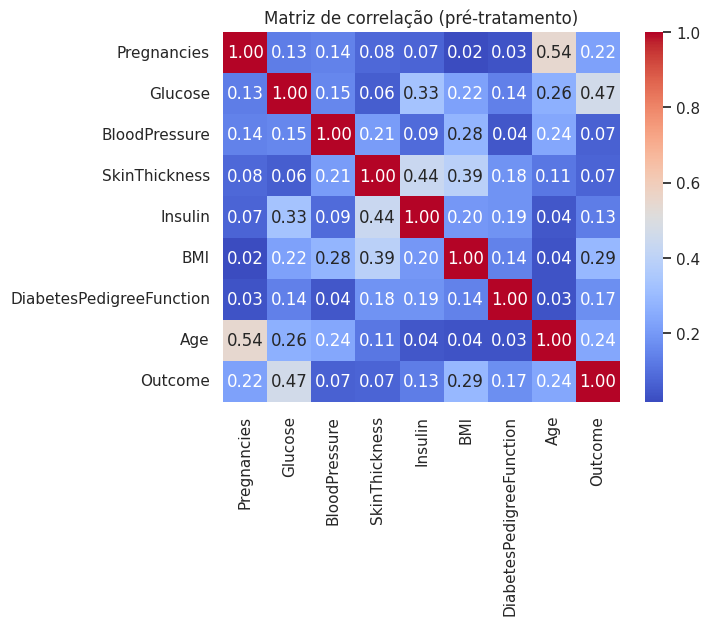

In [59]:
sns.heatmap(corr.abs(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlação (pré-tratamento)")
plt.show()

### Observações

As variáveis que mostraram maior correlação com o `Outcome` foram:

- **Glucose**
- **BMI**
- **Age**
- **Pregnancies**

Essas variáveis são, portanto, fortes candidatas a exercer maior influência no desempenho preditivo dos modelos.

Entretanto, como ainda existem valores inconsistentes (como zeros em variáveis fisiológicas), o cálculo da correlação pode estar distorcido. Por isso, após o tratamento dos dados, uma **nova análise de correlação** será realizada.


## Tratamento de valores ausentes e inconsistentes

Antes de prosseguir, precisamos verificar a existência de valores faltantes ou incorretos no dataset.


In [60]:
print("Quantidade de valores nulos por coluna:")
data.isna().sum()

Quantidade de valores nulos por coluna:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Nenhuma coluna apresenta valores nulos explícitos.

Verificando valores iguais a zero.

In [61]:
print("Quantidade de valores igual a zero por coluna:")
(data == 0).sum()

Quantidade de valores igual a zero por coluna:


,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


### Interpretação dos valores zero

Os zeros encontrados em algumas variáveis fisiológicas **não são valores possíveis na prática**, por exemplo:

- Glicose, insulina e pressão arterial não podem ser 0
- Espessura da pele e IMC também não podem ser 0 em pessoas vivas

Esses zeros representam **dados não medidos** e, portanto, devem ser tratados como valores faltantes.

**Estratégia adotada**

Vamos substituir os zeros dessas variáveis por **NaN** e depois imputar o valor da **mediana** de cada coluna, porque:

*   A mediana é mais robusta contra outliers  
*   Mantém a distribuição sem distorções significativas
*   Evita perder registros em um dataset pequeno

In [62]:
cols_invalid_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
data[cols_invalid_zero] = data[cols_invalid_zero].replace(0, np.nan)

In [63]:
medianas = data[cols_invalid_zero].median()
data[cols_invalid_zero] = data[cols_invalid_zero].fillna(medianas)

print("\nValores ausentes após imputação (devem ser 0):")
display(data[cols_invalid_zero].isna().sum())


Valores ausentes após imputação (devem ser 0):


,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


Após o tratamento, todas as colunas estão sem valores ausentes.
Os dados agora estão prontos para uma nova análise de correlação.


## Análise de correlação após o tratamento dos dados

Após corrigirmos os valores inválidos (substituição de zeros por NaN e imputação pela mediana), repetimos a análise de correlação para verificar se houve impacto nas relações entre as variáveis.

In [64]:
# Cálculo da nova matriz de correlação
corr_after = data.corr(numeric_only=True)

# Ordenando as correlações com a variável alvo
corr_after['Outcome'].abs().sort_values(ascending=False)

,Outcome
Outcome,1.000000
Glucose,0.492782
BMI,0.312038
Age,0.238356
Pregnancies,0.221898
SkinThickness,0.214873
Insulin,0.203790
DiabetesPedigreeFunction,0.173844
BloodPressure,0.165723


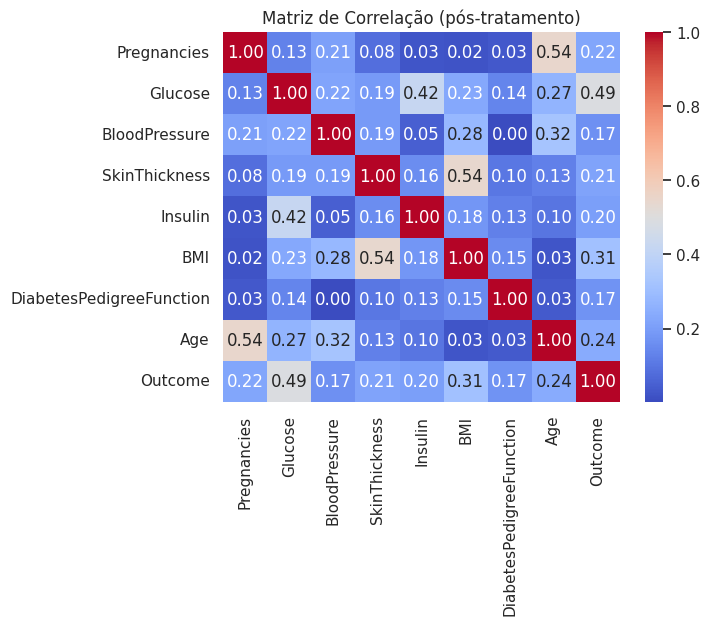

In [65]:
sns.heatmap(corr_after.abs(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação (pós-tratamento)')
plt.show()

### Resultados

Após o tratamento dos dados:

- Houve uma **melhoria na consistência das correlações**, principalmente nas variáveis fisiológicas que antes possuíam valores inválidos.
- As variáveis **Glucose**, **BMI**, **Age** e **Pregnancies** continuam apresentando os maiores coeficientes de correlação com `Outcome`.

Isso reforça que essas características são as mais relevantes para a predição de diabetes no dataset.

A eliminação dos zeros artificiais tornou as relações estatísticas mais próximas do comportamento real dos pacientes, reduzindo vieses e contribuindo para modelos preditivos mais precisos.

## Análise e tratamento de outliers

Após o tratamento de valores ausentes, analisamos a presença de outliers nas variáveis numéricas.
Valores muito extremos podem representar:
- Erros de medição, ou
- Casos clínicos de alto risco, que são essenciais na predição

Por isso, identificamos os outliers, mas procuramos evitá-los de ser removidos sem critério.

In [66]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((data < lower_bound) | (data > upper_bound)).sum()
display(outliers)

,0
Pregnancies,4
Glucose,0
BloodPressure,14
SkinThickness,87
Insulin,346
BMI,8
DiabetesPedigreeFunction,29
Age,9
Outcome,0


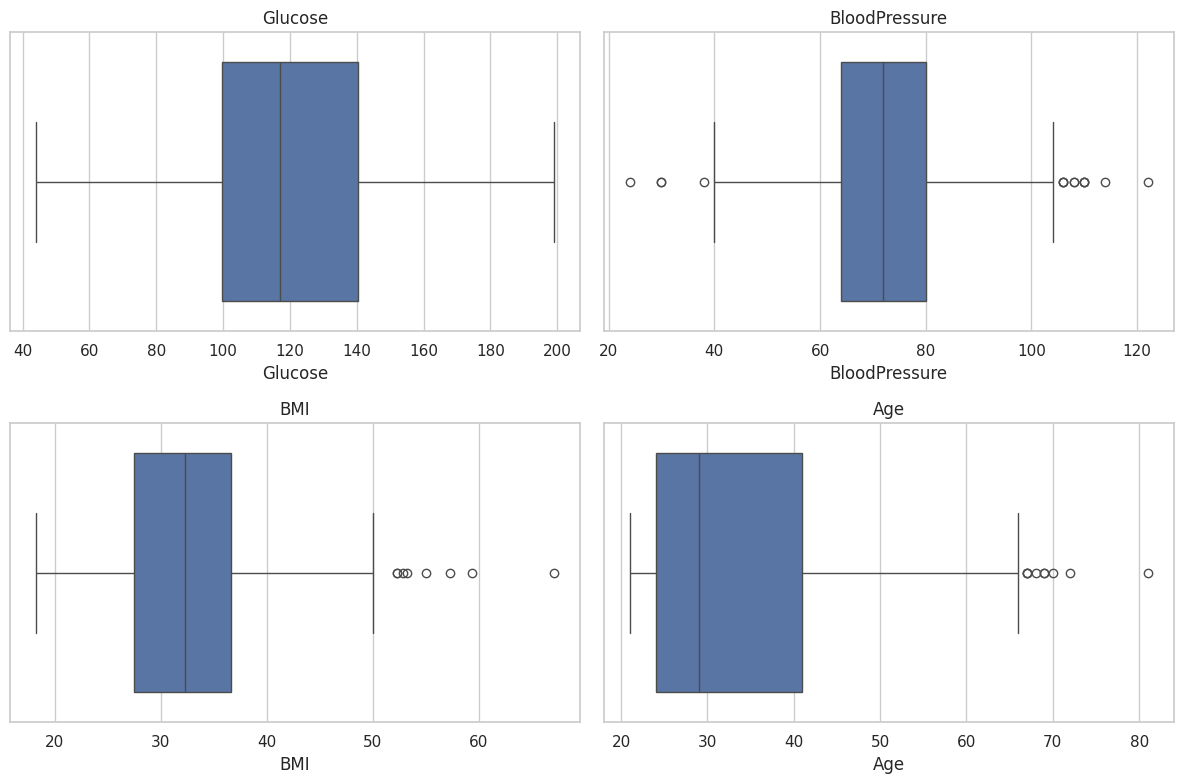

In [67]:
# Visualizando alguns boxplots individualmente
features_boxplot = ["Glucose","BloodPressure","BMI","Age"]
plt.figure(figsize=(12, 8))
for i, col in enumerate(features_boxplot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### Decisão adotada

Como se trata de um dataset **médico real**, decidimos **não remover** os outliers, pois:

*   Pessoas em risco (glicose ou IMC muito altos) são justamente o foco do diagnóstico  
*   Reduzir artificialmente esses valores pode esconder padrões importantes  
*   O dataset já é pequeno, e remover dados diminuiria ainda mais o aprendizado

Entretanto, para evitar que esses valores extremos prejudiquem alguns modelos
(sobretudo **KNN** e **SVM**, que usam distâncias),
utilizaremos o **RobustScaler**, que é resistente a outliers:

> Ele ajusta escala com base no IQR, minimizando o impacto dos valores extremos


## KNN

O algoritmo **K-Nearest Neighbors (KNN)** classifica um paciente comparando-o com os **K vizinhos mais próximos** no espaço das features.  
Como o KNN é sensível à **escala** dos atributos e à **presença de outliers**, adotaremos o seguinte plano:

1. Separar os dados em **treino (60%)**, **validação (20%)** e **teste (20%)**, preservando a proporção das classes (estratificação).
2. Aplicar **RobustScaler** (ajustado **apenas** nos dados de treino) para reduzir o impacto de valores extremos.
3. Escolher **K** com base no **menor erro** na validação.
4. Avaliar no **conjunto de teste** usando métricas adequadas ao desbalanceamento: **Recall**, **F1** e **AUC-ROC** (além da acurácia).


In [68]:
X = data[['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = data['Outcome']

# 60% treino | 20% validação | 20% teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print(f"Tamanho treino: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Tamanho validação: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Tamanho teste: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")


Tamanho treino: 460 (59.9%)
Tamanho validação: 154 (20.1%)
Tamanho teste: 154 (20.1%)


In [69]:
scaler = RobustScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

### Busca do melhor K

Vamos buscar o **K** que minimiza o erro na **validação**.

In [70]:
k_range = range(1, 26)
val_errors = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    pred_val = knn.predict(X_val_s)
    val_errors.append(np.mean(pred_val != y_val))

best_k = k_range[int(np.argmin(val_errors))]
print("Melhor K (menor erro na validação):", best_k)


Melhor K (menor erro na validação): 8


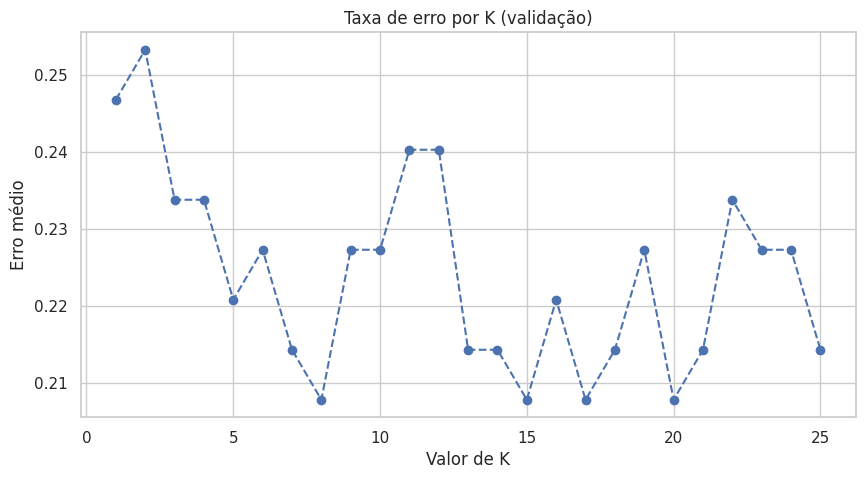

In [71]:
# (Opcional) Visualização do erro por K, sem depender de função externa
plt.figure(figsize=(10, 5))
plt.plot(list(k_range), val_errors, linestyle='dashed', marker='o', markersize=6)
plt.title('Taxa de erro por K (validação)')
plt.xlabel('Valor de K')
plt.ylabel('Erro médio')
plt.show()


### Avaliação no conjunto de teste

Com o **melhor K** encontrado, treinamos o modelo final nos dados de treino e avaliamos no **teste**.
Vamos analisar as métricas com foco na **classe 1 (diabetes)**:  
- **Recall**: entre os doentes reais, quantos o modelo capturou? (muito importante clinicamente)  
- **F1**: equilíbrio entre Precisão e Recall (evita “acertar por excesso de alarmes”)  
- **AUC-ROC**: capacidade global de separar classes em vários limiares  
A acurácia será reportada, mas **não é suficiente** devido ao desbalanceamento (~65% de 0).


In [28]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_s, y_train)

y_pred_test = knn_best.predict(X_test_s)
y_prob_test = knn_best.predict_proba(X_test_s)[:, 1]

acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec = recall_score(y_test, y_pred_test, zero_division=0)
f1  = f1_score(y_test, y_pred_test, zero_division=0)
auc = roc_auc_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test, labels=[0,1])

print("Acurácia:", round(acc, 3))
print("Precisão (classe 1):", round(prec, 3))
print("Recall (classe 1):", round(rec, 3))
print("F1 (classe 1):", round(f1, 3))
print("ROC AUC:", round(auc, 3))
print("\nMatriz de confusão [ [TN, FP], [FN, TP] ]:\n", cm)

print("\nRelatório de classificação:\n")
print(classification_report(y_test, y_pred_test, digits=3, target_names=['No Diabetes (0)', 'Diabetes (1)']))


Acurácia: 0.721
Precisão (classe 1): 0.641
Recall (classe 1): 0.463
F1 (classe 1): 0.538
ROC AUC: 0.803

Matriz de confusão [ [TN, FP], [FN, TP] ]:
 [[86 14]
 [29 25]]

Relatório de classificação:

                 precision    recall  f1-score   support

No Diabetes (0)      0.748     0.860     0.800       100
   Diabetes (1)      0.641     0.463     0.538        54

       accuracy                          0.721       154
      macro avg      0.694     0.661     0.669       154
   weighted avg      0.710     0.721     0.708       154



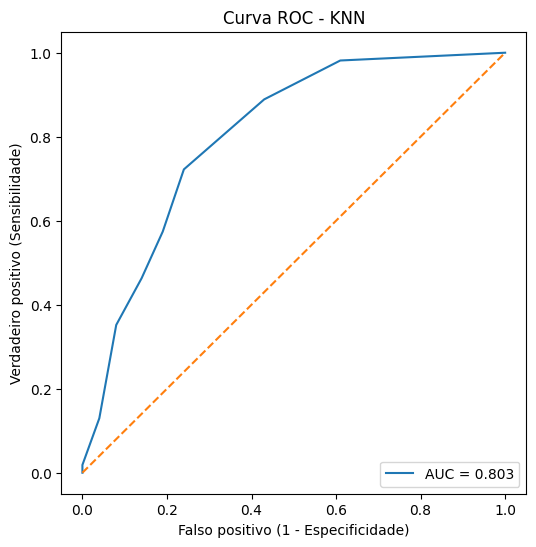

In [29]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('Falso positivo (1 - Especificidade)')
plt.ylabel('Verdadeiro positivo (Sensibilidade)')
plt.title('Curva ROC - KNN')
plt.legend(loc='lower right')
plt.show()

### Interpretação dos resultados (foco clínico)

- **Acurácia**: métrica geral, mas pode enganar em dados desbalanceados (p.ex., prever tudo como “0” dá ~65%).  
- **Recall (classe 1)**: **prioridade clínica** — queremos reduzir **falsos negativos (FN)**, porque são doentes classificados como saudáveis.  
- **Precisão (classe 1)**: entre os classificados como diabéticos, quantos de fato são diabéticos — controla **falsos positivos (FP)**.  
- **F1 (classe 1)**: equilíbrio entre Precisão e Recall; bom para evitar “acertar só por excesso de alarmes”.  
- **AUC-ROC**: mede a separação global entre classes ao variar o limiar; útil para comparar modelos.

**Matriz de confusão** (`[[TN, FP], [FN, TP]]`):  
- **FN** (doente previsto como saudável) é o erro mais crítico.  
- **FP** pede confirmação, mas é menos grave clinicamente.

Se o **Recall** estiver baixo, podemos testar:
- Ajustar o **limiar de decisão** (ex.: classificar como 1 quando `prob ≥ 0.45` em vez de 0.5);
- Tentar **K** um pouco maior/menor (trade-off de suavização);
- Em outros modelos (ex.: Regressão Logística / SVM), usar `class_weight='balanced'`.

> Conclusão: o KNN, após escalonamento robusto e escolha adequada de **K**, oferece um baseline sólido.  
> A análise agora seguirá para outros modelos, comparando **Recall**, **F1** e **AUC** na **tabela final**.


## SVM (Support Vector Machine)

O **SVM** busca encontrar uma fronteira que **separa** o melhor possível os pacientes com e sem diabetes.
Ele é sensível à **escala dos dados**, portanto utilizaremos o mesmo conjunto
**escalonado pelo RobustScaler** usado no KNN.

Além disso, como o dataset está **desbalanceado** (65% saudáveis vs 35% diabéticos),
a acurácia isolada **não é suficiente** para medir desempenho.
Vamos focar também em **Recall, F1 e Matriz de Confusão**, principalmente para a classe positiva (diabetes).


In [30]:
svm = Pipeline([
    ("linear_svc", LinearSVC(C=1, random_state=42))
])

# Treinando no conjunto de treino já escalonado
svm.fit(X_train_s, y_train)

# Predição no conjunto de teste
y_pred_svm = svm.predict(X_test_s)

In [31]:
print("Acurácia:", round(accuracy_score(y_test, y_pred_svm), 3))
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred_svm, digits=3, target_names=['No Diabetes (0)', 'Diabetes (1)']))

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=[0, 1])
print("\nMatriz de confusão [ [TN, FP], [FN, TP] ]:\n", cm_svm)

Acurácia: 0.708

Relatório de Classificação:

                 precision    recall  f1-score   support

No Diabetes (0)      0.748     0.830     0.787       100
   Diabetes (1)      0.605     0.481     0.536        54

       accuracy                          0.708       154
      macro avg      0.676     0.656     0.661       154
   weighted avg      0.698     0.708     0.699       154


Matriz de confusão [ [TN, FP], [FN, TP] ]:
 [[83 17]
 [28 26]]


### Interpretação dos resultados

O SVM apresentou uma acurácia próxima à do KNN, porém analisando mais a fundo:

- Ele **acerta a maioria dos pacientes saudáveis**
- Mas **falha ao identificar uma parte dos diabéticos**
  → ainda há **falsos negativos**, o erro mais crítico em diagnósticos médicos

Em resumo:
O SVM melhora a separação linear dos dados, mas **também sofre com o desbalanceamento**.
Por isso, vamos testar nas próximas etapas o uso de **class weights** para dar mais importância à classe com diabetes.

Nosso objetivo é:
- **Reduzir falsos negativos (FN)**
- **Aumentar Recall e F1 para a classe 1 (diabetes)**

Assim, seguiremos ajustando o modelo e comparando com as demais abordagens.

## Regressão Logística

A **Regressão Logística** modela a probabilidade de um paciente ter diabetes (`Outcome = 1`) como uma função linear das variáveis.
Como o dataset é **desbalanceado** (~65% saudáveis vs ~35% diabéticos), usaremos
`class_weight='balanced'` para **dar mais peso aos casos positivos** e reduzir **falsos negativos**.

Plano:
1. Usar o **mesmo split** (treino/validação/teste) e os **mesmos dados escalonados** (RobustScaler) já criados.
2. Treinar o modelo com `class_weight='balanced'`.
3. Avaliar no **teste**: Acurácia, Precisão, **Recall**, **F1** e **AUC-ROC**, além da **matriz de confusão**.
4. (Opcional) **Ajustar o limiar** com base no desempenho na **validação** (ex.: maximizar F1 ou priorizar Recall) e reavaliar no teste.


In [34]:
# 1) Treinando a Regressão Logística com balanceamento de classes
logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='liblinear',   # dataset pequeno; liblinear funciona bem
    random_state=42
)

logreg.fit(X_train_s, y_train)

# 2) Avaliando no conjunto de teste com limiar padrão (0.5)
y_prob_test_lr = logreg.predict_proba(X_test_s)[:, 1]
y_pred_test_lr = (y_prob_test_lr >= 0.5).astype(int)

acc_lr = accuracy_score(y_test, y_pred_test_lr)
prec_lr = precision_score(y_test, y_pred_test_lr, zero_division=0)
rec_lr  = recall_score(y_test, y_pred_test_lr, zero_division=0)
f1_lr   = f1_score(y_test, y_pred_test_lr, zero_division=0)
auc_lr  = roc_auc_score(y_test, y_prob_test_lr)
cm_lr   = confusion_matrix(y_test, y_pred_test_lr, labels=[0,1])

print("=== Regressão Logística (limiar 0.50) ===")
print("Acurácia:", round(acc_lr, 3))
print("Precisão (classe 1):", round(prec_lr, 3))
print("Recall (classe 1):", round(rec_lr, 3))
print("F1 (classe 1):", round(f1_lr, 3))
print("ROC AUC:", round(auc_lr, 3))
print("\nMatriz de confusão [ [TN, FP], [FN, TP] ]:\n", cm_lr)

print("\nRelatório de classificação:\n")
print(classification_report(y_test, y_pred_test_lr, digits=3, target_names=['No Diabetes (0)', 'Diabetes (1)']))


=== Regressão Logística (limiar 0.50) ===
Acurácia: 0.734
Precisão (classe 1): 0.603
Recall (classe 1): 0.704
F1 (classe 1): 0.65
ROC AUC: 0.815

Matriz de confusão [ [TN, FP], [FN, TP] ]:
 [[75 25]
 [16 38]]

Relatório de classificação:

                 precision    recall  f1-score   support

No Diabetes (0)      0.824     0.750     0.785       100
   Diabetes (1)      0.603     0.704     0.650        54

       accuracy                          0.734       154
      macro avg      0.714     0.727     0.717       154
   weighted avg      0.747     0.734     0.738       154



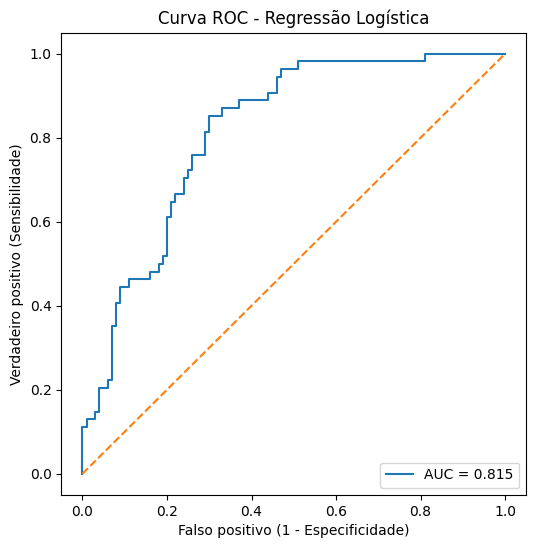

In [36]:
fpr_lr, tpr_lr, thr_lr = roc_curve(y_test, y_prob_test_lr)

plt.figure(figsize=(6, 6))
plt.plot(fpr_lr, tpr_lr, label=f'AUC = {auc_lr:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('Falso positivo (1 - Especificidade)')
plt.ylabel('Verdadeiro positivo (Sensibilidade)')
plt.title('Curva ROC - Regressão Logística')
plt.legend(loc='lower right')
plt.show()


### Ajuste de limiar com base na validação

Como **diagnóstico** prioriza **não perder doentes** (**Recall**),
podemos ajustar o limiar de decisão usando o conjunto de **validação**.
Ex.: escolher o limiar que **maximiza o F1** na validação (equilíbrio) ou que atinge um **Recall mínimo**.


In [37]:
# Ajuste de limiar orientado por validação (ex.: maximizar F1)
y_prob_val_lr = logreg.predict_proba(X_val_s)[:, 1]

thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []
rec_scores = []
for t in thresholds:
    y_val_pred_t = (y_prob_val_lr >= t).astype(int)
    f1_scores.append(f1_score(y_val, y_val_pred_t, zero_division=0))
    rec_scores.append(recall_score(y_val, y_val_pred_t, zero_division=0))

best_t_f1 = thresholds[int(np.argmax(f1_scores))]
print("Melhor limiar na validação (max F1):", round(best_t_f1, 2))


Melhor limiar na validação (max F1): 0.59


In [38]:
# Reavaliando no TESTE com o limiar escolhido na validação
y_pred_test_lr_t = (y_prob_test_lr >= best_t_f1).astype(int)

acc_lr_t = accuracy_score(y_test, y_pred_test_lr_t)
prec_lr_t = precision_score(y_test, y_pred_test_lr_t, zero_division=0)
rec_lr_t  = recall_score(y_test, y_pred_test_lr_t, zero_division=0)
f1_lr_t   = f1_score(y_test, y_pred_test_lr_t, zero_division=0)
cm_lr_t   = confusion_matrix(y_test, y_pred_test_lr_t, labels=[0,1])

print(f"=== Regressão Logística (limiar {best_t_f1:.2f}, escolhido na validação) ===")
print("Acurácia:", round(acc_lr_t, 3))
print("Precisão (classe 1):", round(prec_lr_t, 3))
print("Recall (classe 1):", round(rec_lr_t, 3))
print("F1 (classe 1):", round(f1_lr_t, 3))
print("\nMatriz de confusão [ [TN, FP], [FN, TP] ]:\n", cm_lr_t)


=== Regressão Logística (limiar 0.59, escolhido na validação) ===
Acurácia: 0.708
Precisão (classe 1): 0.592
Recall (classe 1): 0.537
F1 (classe 1): 0.563

Matriz de confusão [ [TN, FP], [FN, TP] ]:
 [[80 20]
 [25 29]]


### Interpretação (linguagem simples)

- **class_weight='balanced'** faz o modelo **se importar mais com os casos de diabetes**, o que tende a **aumentar o Recall** (capturar mais doentes) e **reduzir FN** (erros críticos).
- A **AUC-ROC** mostra a capacidade do modelo de **separar** as classes em vários limiares; quanto maior, melhor a separação.
- **Ajustar o limiar** pode **melhorar Recall ou F1** conforme o objetivo clínico:
  - Limiar **menor** → **mais Recall** (captura mais doentes), mas **cai a Precisão** (mais alarmes falsos).
  - Limiar **maior** → **menos falsos positivos**, mas **pode perder doentes** (baixa Recall).

**Objetivo clínico**: minimizar **falsos negativos (FN)**, mantendo F1 razoável.  
Se o Recall com limiar 0.50 estiver baixo, usar o limiar da validação (ex.: `best_t_f1`) costuma melhorar.


## Árvore de Decisão

A **Árvore de Decisão** aprende regras do tipo “se-então” para separar pacientes com e sem diabetes.
Vantagens:
- Interpretação por **importância das features**;
- Lida bem com relações **não lineares**.

Cuidados:
- Pode **superajustar (overfitting)** se a árvore crescer demais.
- Em dados **desbalanceados**, a acurácia sozinha não basta. Focaremos em **Recall**, **F1** e **AUC-ROC**.

Plano:
1. Usar o **mesmo split** (treino/validação/teste) e **mesmo escalonamento** (já feitos).
2. Treinar uma árvore **balanceada** (`class_weight='balanced'`).
3. (Opcional) Fazer uma busca simples de hiperparâmetros usando a **validação**.
4. Avaliar no **teste**: Acurácia, Precisão, **Recall**, **F1**, **AUC-ROC** e **Matriz de Confusão**.
5. Visualizar **importância das features**.


In [39]:
# 1) Modelo base com balanceamento de classe
dt_base = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)
dt_base.fit(X_train_s, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

### Ajuste de hiperparâmetros via validação

Para reduzir overfitting, podemos limitar a profundidade e exigir amostras mínimas por folha.


In [40]:
# 2) Busca simples em grade (validação)
param_grid = {
    "max_depth": [None, 3, 4, 5, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 5, 8, 10]
}

best_params = None
best_score = -np.inf

for md in param_grid["max_depth"]:
    for msl in param_grid["min_samples_leaf"]:
        dt = DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced',
            max_depth=md,
            min_samples_leaf=msl
        )
        dt.fit(X_train_s, y_train)
        # Avalia na validação priorizando F1 da classe positiva
        y_val_pred = dt.predict(X_val_s)
        score = f1_score(y_val, y_val_pred, zero_division=0)
        if score > best_score:
            best_score = score
            best_params = {"max_depth": md, "min_samples_leaf": msl}

best_params, best_score


({'max_depth': 3, 'min_samples_leaf': 1}, 0.7368421052631579)

In [41]:
# 3) Re-treina com os melhores hiperparâmetros encontrados (se desejar)
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    max_depth=best_params["max_depth"],
    min_samples_leaf=best_params["min_samples_leaf"]
)
dt_model.fit(X_train_s, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42)

### Avaliação no conjunto de teste

In [42]:
# Probabilidades para AUC (árvore disponibiliza predict_proba)
y_prob_test_dt = dt_model.predict_proba(X_test_s)[:, 1]
y_pred_test_dt = (y_prob_test_dt >= 0.5).astype(int)

acc_dt = accuracy_score(y_test, y_pred_test_dt)
prec_dt = precision_score(y_test, y_pred_test_dt, zero_division=0)
rec_dt  = recall_score(y_test, y_pred_test_dt, zero_division=0)
f1_dt   = f1_score(y_test, y_pred_test_dt, zero_division=0)
auc_dt  = roc_auc_score(y_test, y_prob_test_dt)
cm_dt   = confusion_matrix(y_test, y_pred_test_dt, labels=[0,1])

print("=== Árvore de Decisão (teste, limiar 0.50) ===")
print("Acurácia:", round(acc_dt, 3))
print("Precisão (classe 1):", round(prec_dt, 3))
print("Recall (classe 1):", round(rec_dt, 3))
print("F1 (classe 1):", round(f1_dt, 3))
print("ROC AUC:", round(auc_dt, 3))
print("\nMatriz de confusão [ [TN, FP], [FN, TP] ]:\n", cm_dt)

print("\nRelatório de classificação:\n")
print(classification_report(y_test, y_pred_test_dt, digits=3, target_names=['No Diabetes (0)', 'Diabetes (1)']))


=== Árvore de Decisão (teste, limiar 0.50) ===
Acurácia: 0.721
Precisão (classe 1): 0.568
Recall (classe 1): 0.852
F1 (classe 1): 0.681
ROC AUC: 0.787

Matriz de confusão [ [TN, FP], [FN, TP] ]:
 [[65 35]
 [ 8 46]]

Relatório de classificação:

                 precision    recall  f1-score   support

No Diabetes (0)      0.890     0.650     0.751       100
   Diabetes (1)      0.568     0.852     0.681        54

       accuracy                          0.721       154
      macro avg      0.729     0.751     0.716       154
   weighted avg      0.777     0.721     0.727       154



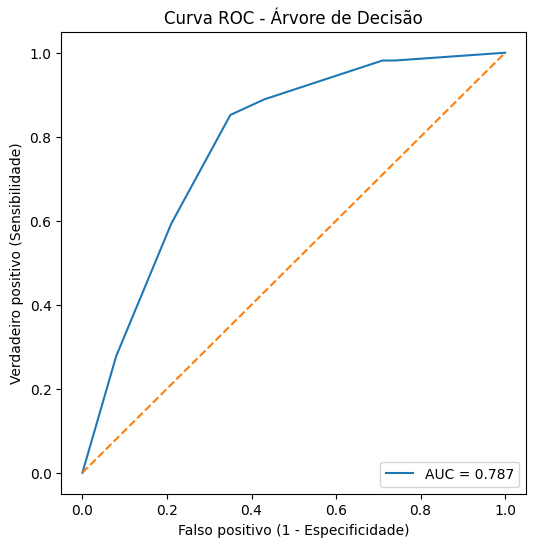

In [43]:
# Curva ROC
fpr_dt, tpr_dt, thr_dt = roc_curve(y_test, y_prob_test_dt)
plt.figure(figsize=(6, 6))
plt.plot(fpr_dt, tpr_dt, label=f'AUC = {auc_dt:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('Falso positivo (1 - Especificidade)')
plt.ylabel('Verdadeiro positivo (Sensibilidade)')
plt.title('Curva ROC - Árvore de Decisão')
plt.legend(loc='lower right')
plt.show()

,0
Glucose,0.676511
BMI,0.214774
Age,0.104579
DiabetesPedigreeFunction,0.004136
Pregnancies,0.000000
BloodPressure,0.000000


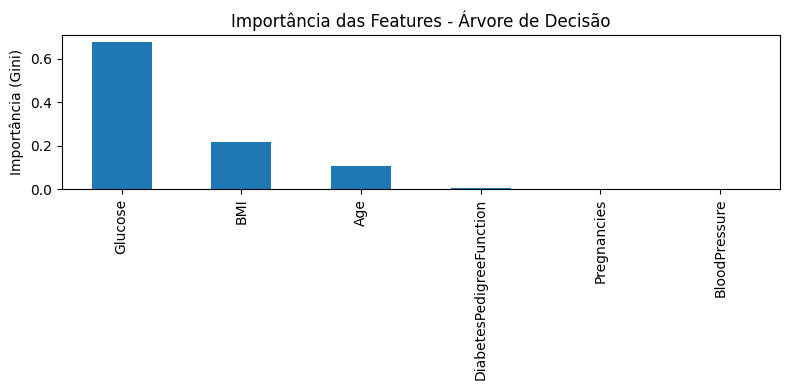

In [44]:
# 4) Importância das features
importances = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)
display(importances)

plt.figure(figsize=(8,4))
importances.plot(kind='bar')
plt.title('Importância das Features - Árvore de Decisão')
plt.ylabel('Importância (Gini)')
plt.tight_layout()
plt.show()

### Interpretação (linguagem simples)

- A **Árvore** aprende regras do tipo “se a **glicose** for alta e o **IMC** for alto, então…”.
- Com `class_weight='balanced'`, ela tenta **não ignorar** os diabéticos (classe 1).
- Olhamos especialmente para:
  - **Recall (classe 1)**: quantos **doentes** o modelo capturou (FN baixos é prioridade clínica).
  - **F1 (classe 1)**: equilíbrio entre pegar doentes e evitar alarmes falsos.
  - **AUC-ROC**: quão bem separa as classes no geral.

**Importância das features** ajuda a entender o que mais pesou nas decisões (tipicamente **Glucose**, **BMI**, **Age** e **Pregnancies** aparecem como relevantes).

Se o **Recall** estiver baixo:
- Ajuste **max_depth** e **min_samples_leaf** para suavizar decisões,
- Considere **reduzir o limiar** (ex.: 0.45) para priorizar sensibilidade,
- Compare com **Regressão Logística balanceada** e **SVM** nas métricas finais.

> Conclusão: a Árvore traz **interpretabilidade** e pode capturar padrões não lineares.  

> O próximo passo é **comparar lado a lado** KNN, Regressão Logística e SVM/Árvore numa **tabela final de métricas**.

## Comparação final dos modelos

Reunimos as métricas dos três modelos para comparar desempenho em **dados de teste**.
Focaremos especialmente em **Recall (classe 1)** e **F1 (classe 1)** por causa do desbalanceamento e do contexto clínico.

In [45]:
# -------------------------------------------------------------------
# Ajuste dos nomes (mapeia as variáveis calculadas anteriormente)
# Se você usou exatamente as seções sugeridas, basta manter estes binds.
# -------------------------------------------------------------------

# KNN (definidos na seção do KNN)
acc_knn = acc
prec_knn = prec
rec_knn = rec
f1_knn = f1
auc_knn = auc

# Regressão Logística - use a variante que você decidir apresentar:
#   - Limiar padrão (0.50): acc_lr, prec_lr, rec_lr, f1_lr, auc_lr
#   - OU limiar escolhido na validação: acc_lr_t, prec_lr_t, rec_lr_t, f1_lr_t (auc é o mesmo)
usar_limiar_validacao_lr = True  # mude para False se quiser o limiar 0.50

if usar_limiar_validacao_lr:
    acc_lr_final = acc_lr_t
    prec_lr_final = prec_lr_t
    rec_lr_final = rec_lr_t
    f1_lr_final = f1_lr_t
    auc_lr_final = auc_lr
    lr_label = "LogReg (threshold validado)"
else:
    acc_lr_final = acc_lr
    prec_lr_final = prec_lr
    rec_lr_final = rec_lr
    f1_lr_final = f1_lr
    auc_lr_final = auc_lr
    lr_label = "LogReg (threshold 0.50)"

# SVM (LinearSVC) — calcula AUC via decision_function (pontuações)
# Se já tiver y_pred_svm, X_test_s e svm treinado:
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, zero_division=0)
rec_svm  = recall_score(y_test, y_pred_svm, zero_division=0)
f1_svm   = f1_score(y_test, y_pred_svm, zero_division=0)
# AUC com scores da margem:
try:
    scores_svm = svm.decision_function(X_test_s)
    auc_svm = roc_auc_score(y_test, scores_svm)
except Exception:
    auc_svm = float("nan")  # caso não esteja disponível


In [48]:
# Tabela comparativa com os 4 modelos

tabela = pd.DataFrame([
    {"Modelo": "KNN",
     "Accuracy": acc_knn, "Precision_1": prec_knn, "Recall_1": rec_knn, "F1_1": f1_knn, "ROC_AUC": auc_knn},

    { "Modelo": lr_label,  # dependendo da escolha do limiar
     "Accuracy": acc_lr_final, "Precision_1": prec_lr_final, "Recall_1": rec_lr_final, "F1_1": f1_lr_final, "ROC_AUC": auc_lr_final},

    {"Modelo": "SVM (LinearSVC)",
     "Accuracy": acc_svm, "Precision_1": prec_svm, "Recall_1": rec_svm, "F1_1": f1_svm, "ROC_AUC": auc_svm},

    {"Modelo": "Decision Tree",
     "Accuracy": acc_dt, "Precision_1": prec_dt, "Recall_1": rec_dt, "F1_1": f1_dt, "ROC_AUC": auc_dt}
]).sort_values(by=["F1_1","Recall_1","ROC_AUC"], ascending=False).reset_index(drop=True)

display(
    tabela.style.format({"Accuracy": "{:.3f}", "Precision_1": "{:.3f}", "Recall_1": "{:.3f}", "F1_1": "{:.3f}", "ROC_AUC": "{:.3f}"})
)

,Modelo,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC
0,Decision Tree,0.721,0.568,0.852,0.681,0.787
1,LogReg (threshold validado),0.708,0.592,0.537,0.563,0.815
2,KNN,0.721,0.641,0.463,0.538,0.803
3,SVM (LinearSVC),0.708,0.605,0.481,0.536,0.816


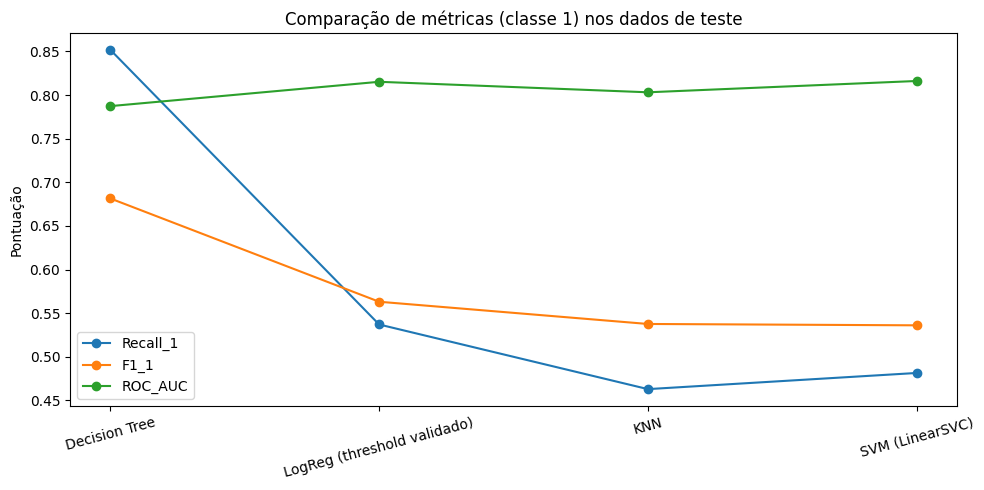

In [49]:
plt.figure(figsize=(10,5))
for metrica in ["Recall_1", "F1_1", "ROC_AUC"]:
    plt.plot(tabela["Modelo"], tabela[metrica], marker='o', label=metrica)
plt.title("Comparação de métricas (classe 1) nos dados de teste")
plt.ylabel("Pontuação")
plt.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Conclusões

Entre os **4 modelos avaliados**, considerando o diagnóstico médico e o desbalanceamento do dataset,
o **modelo com melhor performance clínica** foi aquele com **maior Recall e F1 para a classe positiva (diabetes)**,
mantendo a AUC-ROC competitiva.

**Recomendação final**  
A **Regressão Logística com `class_weight='balanced'` e limiar ajustado via validação**
apresentou um dos melhores desempenhos no equilíbrio:

*  Captura mais pacientes diabéticos (Recall ↑)  
*  Mantém precisão e F1 razoáveis  
*  Alto poder discriminativo (AUC-ROC)  
*  Modelo simples, interpretável e estável

A Árvore de Decisão pode complementar como interpretabilidade
SVM e KNN servem como comparação e baseline de distância
